Single Tree          Train Error=0.0000 Test Error=0.2080
AdaBoost Stump       Train Error=0.1165 Test Error=0.1733
AdaBoost Depth 3     Train Error=0.0230 Test Error=0.0849
Bagging              Train Error=0.0000 Test Error=0.1291
Random Forest        Train Error=0.0000 Test Error=0.1192
Gradient Boosting    Train Error=0.0200 Test Error=0.1016
XGBoost              Train Error=0.0000 Test Error=0.0961


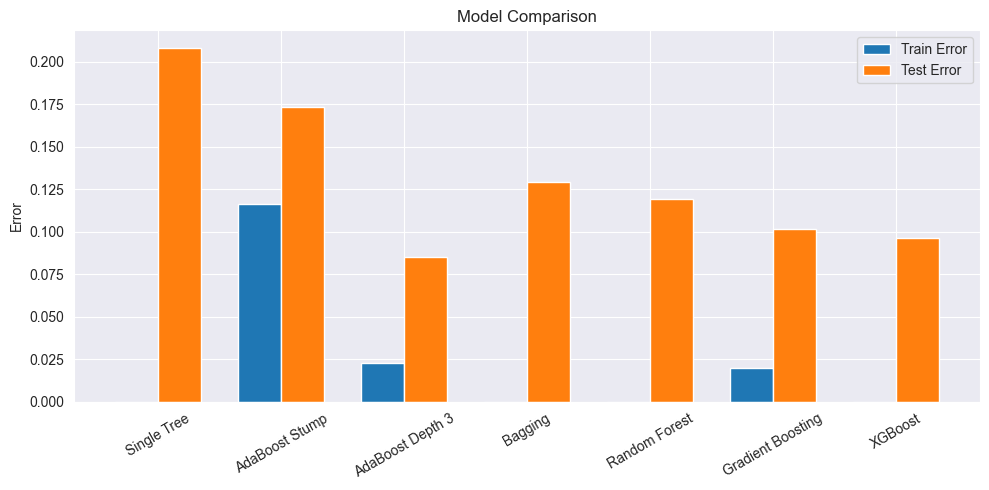

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from abc import ABC, abstractmethod
from scipy.stats import chi2

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier


# =====================================================
# Base Interface
# =====================================================

class EnsembleModel(ABC):

    @abstractmethod
    def fit(self, X, y):
        pass

    @abstractmethod
    def predict(self, X):
        pass


# =====================================================
# Tree Factory
# =====================================================

class TreeFactory:

    @staticmethod
    def create(max_depth=1):
        return DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=42
        )


# =====================================================
# Custom AdaBoost
# =====================================================

class AdaBoostCustom(EnsembleModel):

    def __init__(self, n_estimators=100, max_depth=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth

        self.models = []
        self.betas = []

        self.train_errors = []
        self.test_errors = []

    def fit(self, X, y):

        n = len(y)

        weights = np.ones(n) / n

        self.models = []
        self.betas = []

        for k in range(self.n_estimators):

            clf = TreeFactory.create(self.max_depth)

            clf.fit(
                X,
                y,
                sample_weight=weights
            )

            pred = clf.predict(X)

            incorrect = (pred != y)

            epsilon = np.sum(weights * incorrect)

            # Case epsilon = 0
            if epsilon == 0:
                self.models.append(clf)
                self.betas.append(1e-10)

                print(
                    f"Early stop at iteration {k+1}: "
                    "perfect classifier."
                )
                break

            # Case epsilon >= 0.5
            if epsilon >= 0.5:
                print(
                    f"Early stop at iteration {k+1}: "
                    "classifier not better than random."
                )
                break

            beta = epsilon / (1 - epsilon)

            self.models.append(clf)
            self.betas.append(beta)

            weights[~incorrect] *= beta

            weights /= np.sum(weights)

    def predict(self, X):

        if len(self.models) == 0:
            raise ValueError("Model not trained.")

        classes = np.unique(
            np.concatenate(
                [m.predict(X[:1])
                 for m in self.models]
            )
        )

        votes = np.zeros(
            (X.shape[0], len(classes))
        )

        for clf, beta in zip(
                self.models,
                self.betas):

            alpha = np.log(1 / beta)

            pred = clf.predict(X)

            for idx, cls in enumerate(classes):
                votes[:, idx] += (
                    (pred == cls) * alpha
                )

        return classes[
            np.argmax(votes, axis=1)
        ]


# =====================================================
# Artificial Dataset Generator
# =====================================================

class ArtificialDatasetGenerator:

    def __init__(
            self,
            n_features=10,
            random_state=42):

        self.n_features = n_features
        self.random_state = random_state

    def generate(self, n_samples):

        rng = np.random.default_rng(
            self.random_state
        )

        X = rng.normal(
            0,
            1,
            size=(n_samples,
                  self.n_features)
        )

        threshold = chi2.ppf(
            0.5,
            df=self.n_features
        )

        radius = np.sum(
            X**2,
            axis=1
        )

        y = np.where(
            radius > threshold,
            1,
            -1
        )

        return X, y


# =====================================================
# Wrapper Models
# =====================================================

class SingleTreeModel(EnsembleModel):

    def __init__(self, max_depth=None):
        self.model = DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=42
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


class BaggingModel(EnsembleModel):

    def __init__(self, n_estimators=100):
        self.model = BaggingClassifier(
            n_estimators=n_estimators,
            random_state=42
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


class RandomForestModel(EnsembleModel):

    def __init__(self, n_estimators=100):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=42
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


class GradientBoostingModel(EnsembleModel):

    def __init__(self, n_estimators=100):
        self.model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            random_state=42
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


class XGBoostModel(EnsembleModel):

    def __init__(self, n_estimators=100):
        self.model = XGBClassifier(
            n_estimators=n_estimators,
            random_state=42,
            eval_metric="logloss"
        )

    def fit(self, X, y):
        y_binary = (y == 1).astype(int)
        self.model.fit(X, y_binary)

    def predict(self, X):
        pred = self.model.predict(X)
        return np.where(pred == 1, 1, -1)


# =====================================================
# Metrics Tracker
# =====================================================

class MetricsTracker:

    def __init__(self):
        self.results = {}

    def add(self,
            model_name,
            train_error,
            test_error):

        self.results[model_name] = {
            "train_error": train_error,
            "test_error": test_error
        }

    def summary(self):
        return self.results


# =====================================================
# Experiment Runner
# =====================================================

class ExperimentRunner:

    @staticmethod
    def evaluate(
            model,
            X_train,
            y_train,
            X_test,
            y_test):

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_error = (
            1 -
            accuracy_score(
                y_train,
                train_pred
            )
        )

        test_error = (
            1 -
            accuracy_score(
                y_test,
                test_pred
            )
        )

        return train_error, test_error


# =====================================================
# Plotter
# =====================================================

class Plotter:

    @staticmethod
    def compare(results):

        names = list(results.keys())

        train_errors = [
            results[n]["train_error"]
            for n in names
        ]

        test_errors = [
            results[n]["test_error"]
            for n in names
        ]

        x = np.arange(len(names))
        width = 0.35

        plt.figure(figsize=(10, 5))

        plt.bar(
            x - width / 2,
            train_errors,
            width,
            label="Train Error"
        )

        plt.bar(
            x + width / 2,
            test_errors,
            width,
            label="Test Error"
        )

        plt.xticks(
            x,
            names,
            rotation=30
        )

        plt.ylabel("Error")
        plt.title("Model Comparison")
        plt.legend()
        plt.tight_layout()
        plt.show()


# =====================================================
# Example Usage
# =====================================================

generator = ArtificialDatasetGenerator()

X_train, y_train = generator.generate(2000)
X_test, y_test = generator.generate(10000)

models = {
    "Single Tree":
        SingleTreeModel(),

    "AdaBoost Stump":
        AdaBoostCustom(
            n_estimators=100,
            max_depth=1
        ),

    "AdaBoost Depth 3":
        AdaBoostCustom(
            n_estimators=100,
            max_depth=3
        ),

    "Bagging":
        BaggingModel(),

    "Random Forest":
        RandomForestModel(),

    "Gradient Boosting":
        GradientBoostingModel(),

    "XGBoost":
        XGBoostModel()
}

tracker = MetricsTracker()

for name, model in models.items():

    train_error, test_error = (
        ExperimentRunner.evaluate(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )
    )

    tracker.add(
        name,
        train_error,
        test_error
    )

    print(
        f"{name:20s}"
        f" Train Error={train_error:.4f}"
        f" Test Error={test_error:.4f}"
    )

Plotter.compare(
    tracker.summary()
)